In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import ssl
import urllib.request

# Create an unverified context
ssl._create_default_https_context = ssl._create_unverified_context

# Now Seaborn should be able to access the datasets
import seaborn as sns
print(sns.get_dataset_names())


['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic', 'anagrams', 'anagrams', 'anscombe', 'anscombe', 'attention', 'attention', 'brain_networks', 'brain_networks', 'car_crashes', 'car_crashes', 'diamonds', 'diamonds', 'dots', 'dots', 'dowjones', 'dowjones', 'exercise', 'exercise', 'flights', 'flights', 'fmri', 'fmri', 'geyser', 'geyser', 'glue', 'glue', 'healthexp', 'healthexp', 'iris', 'iris', 'mpg', 'mpg', 'penguins', 'penguins', 'planets', 'planets', 'seaice', 'seaice', 'taxis', 'taxis', 'tips', 'tips', 'titanic', 'titanic', 'anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [8]:
df = sns.load_dataset('car_crashes')

In [9]:
df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


In [10]:
df.isnull().sum()

total             0
speeding          0
alcohol           0
not_distracted    0
no_previous       0
ins_premium       0
ins_losses        0
abbrev            0
dtype: int64

In [12]:
df.duplicated().sum()

0

In [14]:
print(df.describe())


           total   speeding    alcohol  not_distracted  no_previous  \
count  51.000000  51.000000  51.000000       51.000000    51.000000   
mean   15.790196   4.998196   4.886784       13.573176    14.004882   
std     4.122002   2.017747   1.729133        4.508977     3.764672   
min     5.900000   1.792000   1.593000        1.760000     5.900000   
25%    12.750000   3.766500   3.894000       10.478000    11.348000   
50%    15.600000   4.608000   4.554000       13.857000    13.775000   
75%    18.500000   6.439000   5.604000       16.140000    16.755000   
max    23.900000   9.450000  10.038000       23.661000    21.280000   

       ins_premium  ins_losses  
count    51.000000   51.000000  
mean    886.957647  134.493137  
std     178.296285   24.835922  
min     641.960000   82.750000  
25%     768.430000  114.645000  
50%     858.970000  136.050000  
75%    1007.945000  151.870000  
max    1301.520000  194.780000  


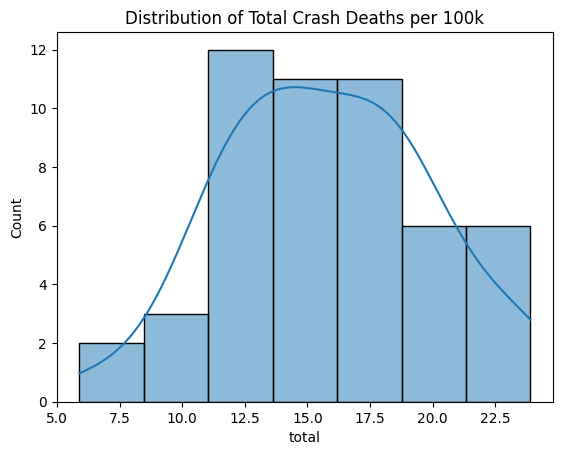

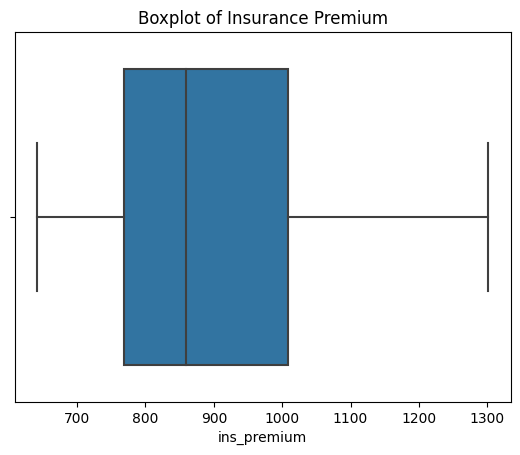

In [15]:
sns.histplot(df['total'], kde=True)
plt.title('Distribution of Total Crash Deaths per 100k')
plt.show()

sns.boxplot(x=df['ins_premium'])
plt.title('Boxplot of Insurance Premium')
plt.show()


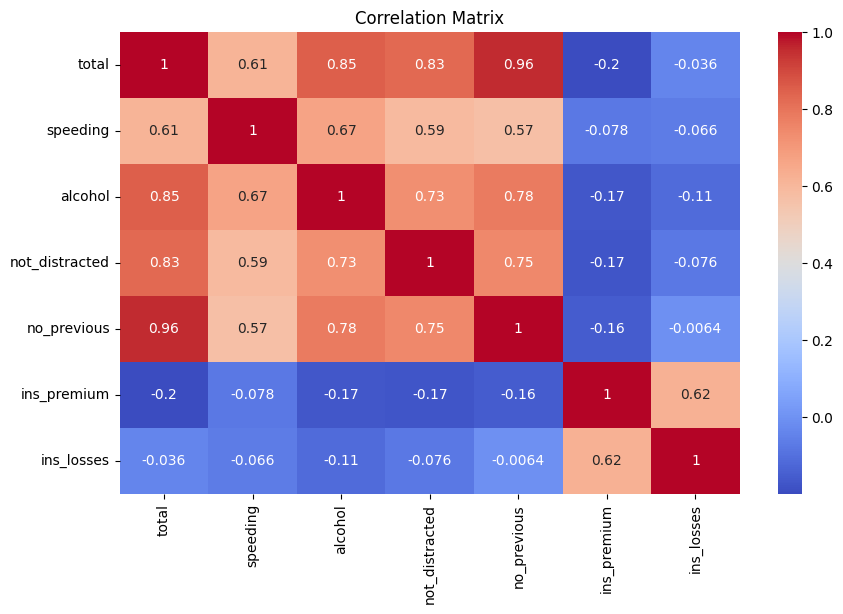

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


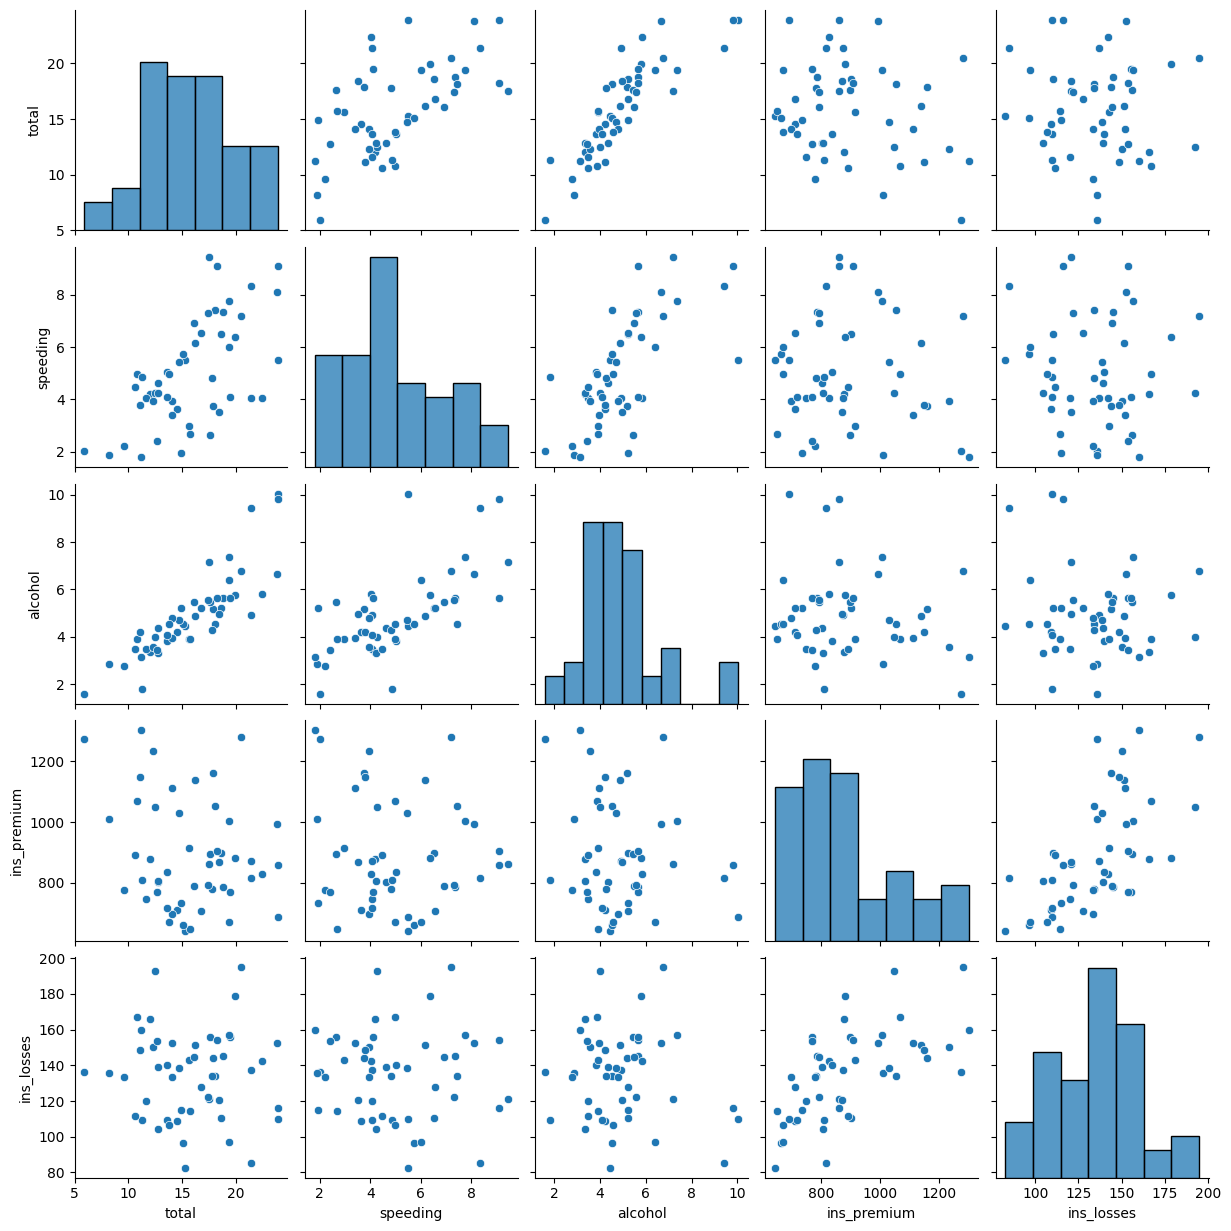

In [17]:
sns.pairplot(df[['total', 'speeding', 'alcohol', 'ins_premium', 'ins_losses']])
plt.show()


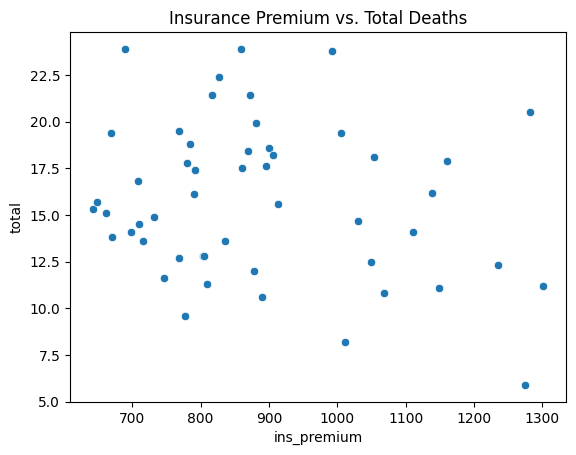

In [18]:
sns.scatterplot(data=df, x='ins_premium', y='total')
plt.title('Insurance Premium vs. Total Deaths')
plt.show()


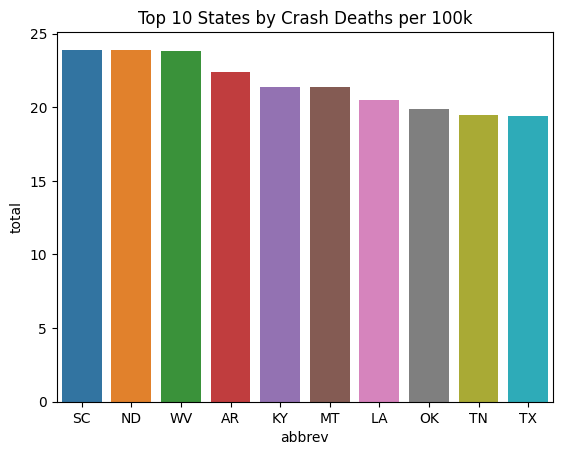

In [19]:
top_states = df.sort_values(by='total', ascending=False).head(10)
sns.barplot(data=top_states, x='abbrev', y='total')
plt.title('Top 10 States by Crash Deaths per 100k')
plt.show()


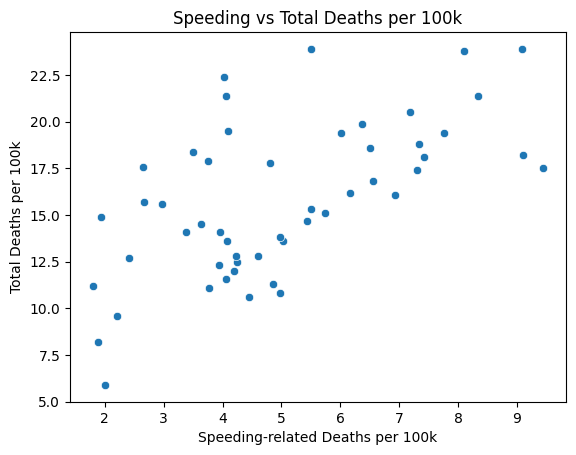

Correlation between speeding and total deaths: 0.61


In [20]:
sns.scatterplot(data=df, x='speeding', y='total')
plt.title('Speeding vs Total Deaths per 100k')
plt.xlabel('Speeding-related Deaths per 100k')
plt.ylabel('Total Deaths per 100k')
plt.show()


correlation = df['speeding'].corr(df['total'])
print(f"Correlation between speeding and total deaths: {correlation:.2f}")

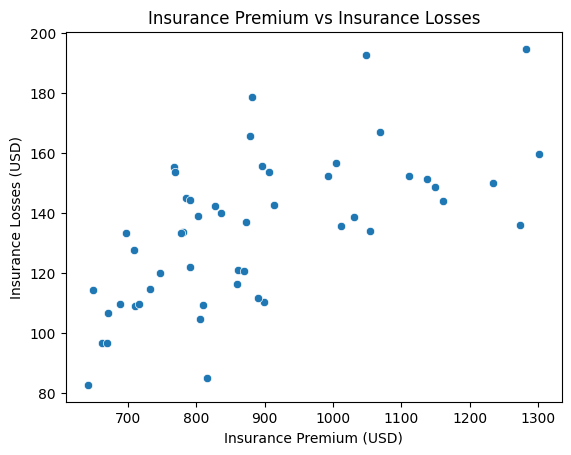

Correlation between insurance premium and insurance losses: 0.62


In [21]:

sns.scatterplot(data=df, x='ins_premium', y='ins_losses')
plt.title('Insurance Premium vs Insurance Losses')
plt.xlabel('Insurance Premium (USD)')
plt.ylabel('Insurance Losses (USD)')
plt.show()


correlation = df['ins_premium'].corr(df['ins_losses'])
print(f"Correlation between insurance premium and insurance losses: {correlation:.2f}")


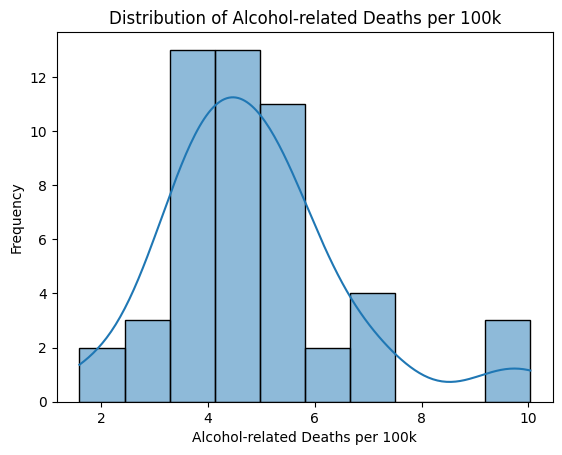

Skewness of alcohol-related deaths: 1.13


In [22]:
sns.histplot(df['alcohol'], kde=True)
plt.title('Distribution of Alcohol-related Deaths per 100k')
plt.xlabel('Alcohol-related Deaths per 100k')
plt.ylabel('Frequency')
plt.show()

skewness = df['alcohol'].skew()
print(f"Skewness of alcohol-related deaths: {skewness:.2f}")


<AxesSubplot:xlabel='total'>

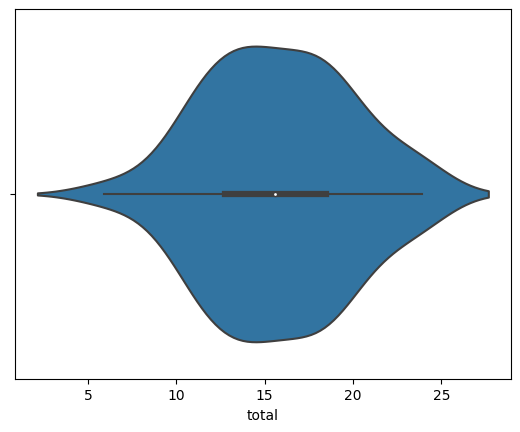

In [23]:
sns.violinplot(x='total', data=df)


In [24]:
df['alcohol_pct'] = df['alcohol'] / df['total']
df['speeding_pct'] = df['speeding'] / df['total']
df['loss_to_premium_ratio'] = df['ins_losses'] / df['ins_premium']


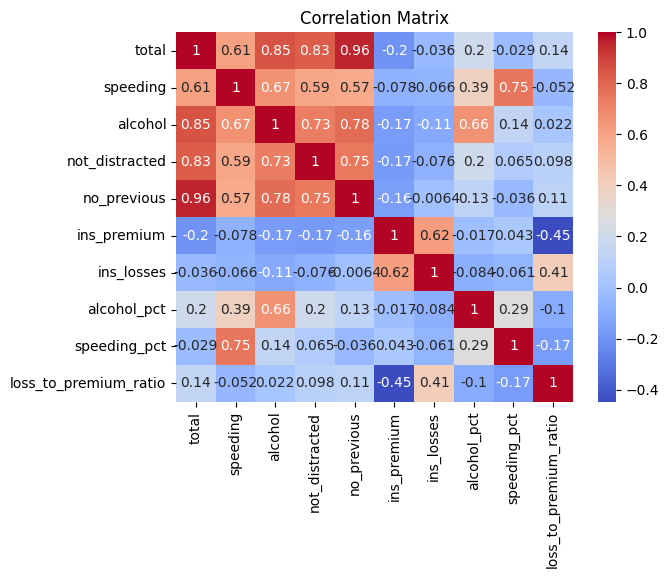

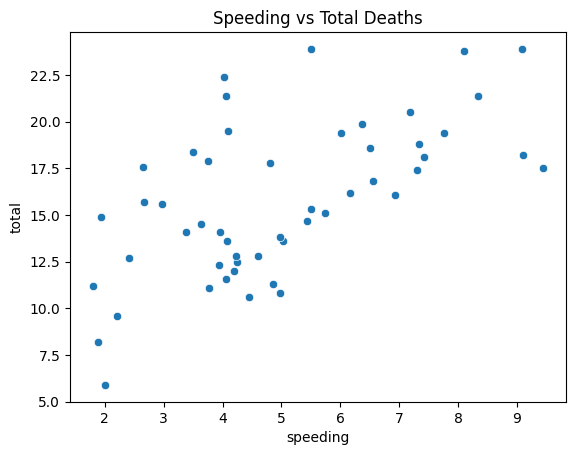

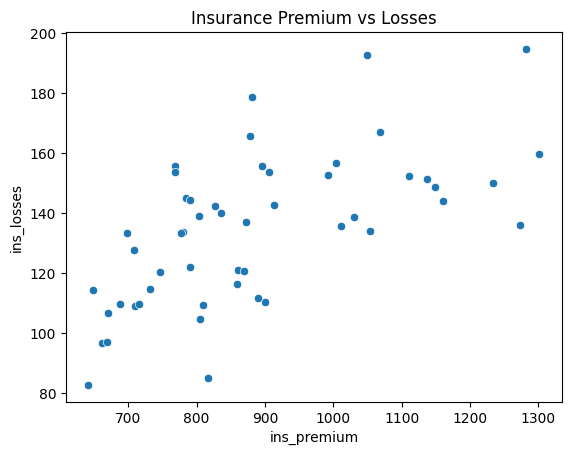

In [25]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

sns.scatterplot(data=df, x='speeding', y='total')
plt.title("Speeding vs Total Deaths")
plt.show()

sns.scatterplot(data=df, x='ins_premium', y='ins_losses')
plt.title("Insurance Premium vs Losses")
plt.show()


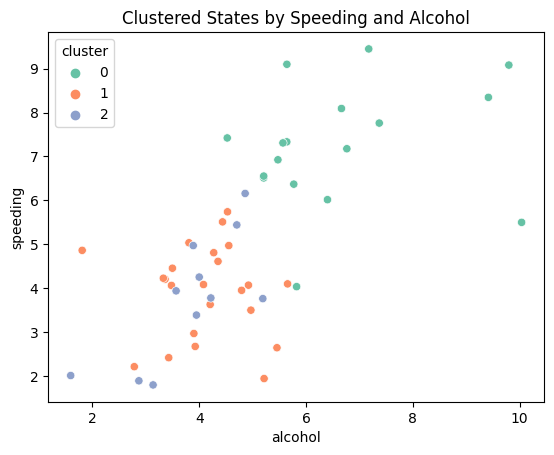

In [26]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = ['speeding', 'alcohol', 'not_distracted', 'ins_premium']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(data=df, x='alcohol', y='speeding', hue='cluster', palette='Set2')
plt.title("Clustered States by Speeding and Alcohol")
plt.show()


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score ,mean_squared_error

# Feature set and target
X = df[['speeding', 'alcohol', 'not_distracted', 'no_previous', 'ins_premium', 'ins_losses']]
y = df['total']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")


R2 Score: 0.88
MSE: 2.19


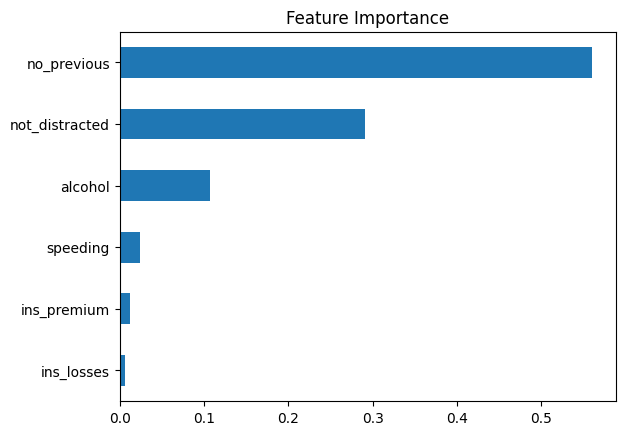

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.sort_values().plot(kind='barh', title='Feature Importance')
plt.show()


In [31]:
import joblib

joblib.dump(rf, 'random_forest_model.pkl')

loaded_model = joblib.load('random_forest_model.pkl')

y_pred_loaded = loaded_model.predict(X_test)
print(f"Predictions from loaded model: {y_pred_loaded[:5]}")


Predictions from loaded model: [19.636 22.085 12.402 16.451 15.766]
